# Chapter 2: How sure can I be?

Companion to `chapter.log`. Both lenses on the same observations.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

from expkit.inference.bayes import coin_posterior_conjugate
from expkit.inference.binomial import binom_test_exact
from expkit.power.binomial import simulate_rejection_rate
from expkit.plot.style import apply_style, PALETTE

apply_style()

## Loop A: the sampling distribution and the rejection region

reject if heads outside (39, 61) at alpha=0.05
P(reject | fair) = 0.0352 (this is alpha empirically)


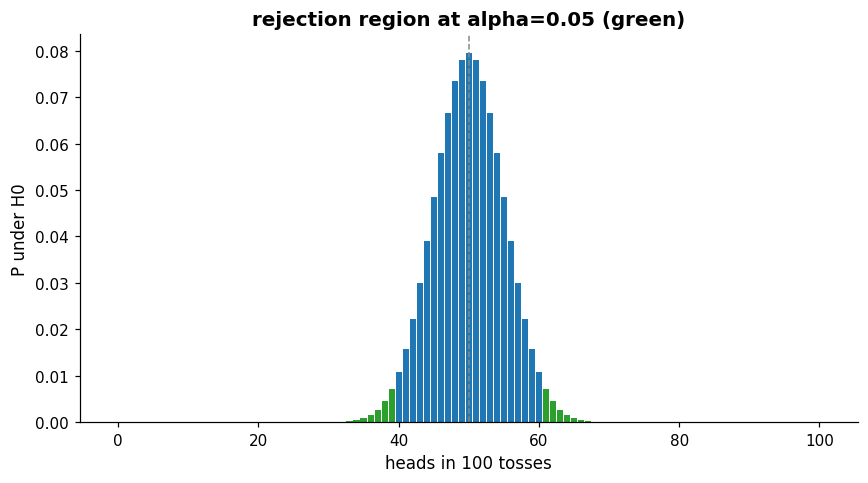

In [2]:
n = 100
counts = np.arange(0, n + 1)
pmf = stats.binom.pmf(counts, n, 0.5)
pvals = np.array([stats.binomtest(int(k), n, p=0.5).pvalue for k in counts])
reject = pvals < 0.05
rej_lo = int(counts[reject][counts[reject] < 50].max()) if (counts[reject] < 50).any() else None
rej_hi = int(counts[reject][counts[reject] > 50].min()) if (counts[reject] > 50).any() else None
print(f'reject if heads outside ({rej_lo}, {rej_hi}) at alpha=0.05')
print(f'P(reject | fair) = {float(pmf[reject].sum()):.4f} (this is alpha empirically)')
fig, ax = plt.subplots()
ax.bar(counts, pmf, color=[PALETTE['highlight'] if r else PALETTE['frequentist'] for r in reject], width=0.9)
ax.axvline(50, color=PALETTE['muted'], linestyle='--', linewidth=1)
ax.set_xlabel('heads in 100 tosses'); ax.set_ylabel('P under H0')
ax.set_title('rejection region at alpha=0.05 (green)')
fig.tight_layout(); plt.show()

## Loop B: both lenses on the same observation

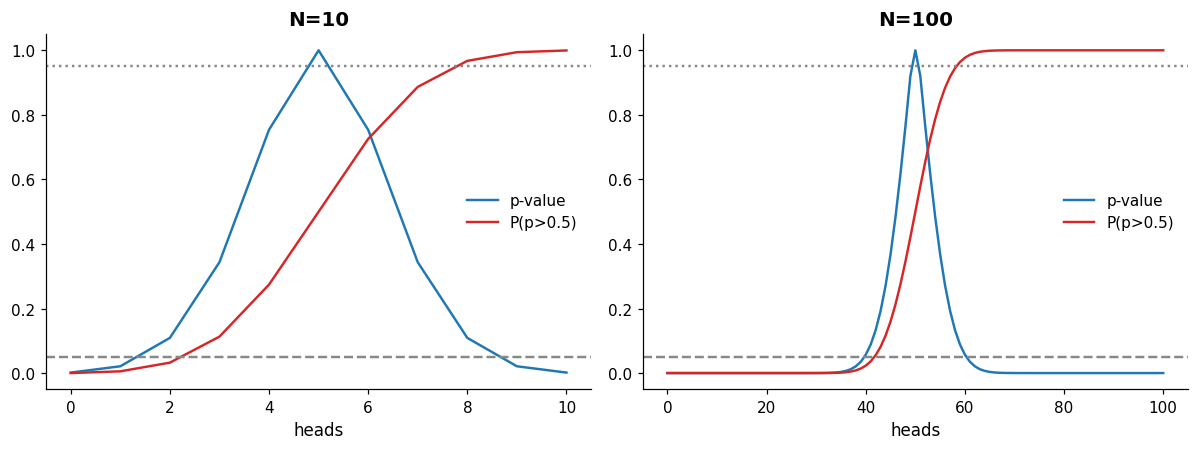

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
for ax, n in zip(axes, [10, 100]):
    ks = np.arange(0, n + 1)
    pvals = np.array([stats.binomtest(int(k), n, p=0.5).pvalue for k in ks])
    posts = np.array([coin_posterior_conjugate(np.array([1]*int(k)+[0]*(n-int(k)))).prob_greater_than(0.5) for k in ks])
    ax.plot(ks, pvals, color=PALETTE['frequentist'], label='p-value')
    ax.plot(ks, posts, color=PALETTE['bayesian'], label='P(p>0.5)')
    ax.axhline(0.05, color=PALETTE['muted'], linestyle='--')
    ax.axhline(0.95, color=PALETTE['muted'], linestyle=':')
    ax.set_title(f'N={n}'); ax.set_xlabel('heads'); ax.legend()
fig.tight_layout(); plt.show()

## Loop C: the same data with three different priors

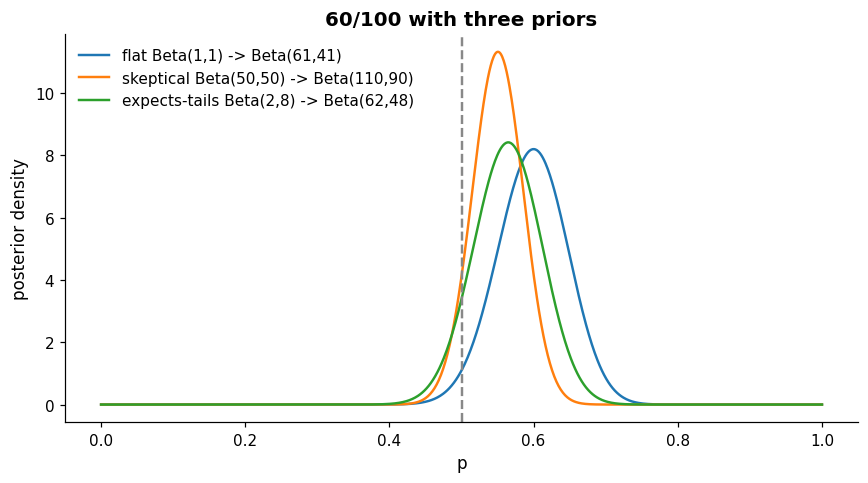

In [4]:
from scipy.stats import beta as beta_dist
data = (60, 100)  # 60 heads in 100 tosses
priors = {'flat Beta(1,1)': (1, 1), 'skeptical Beta(50,50)': (50, 50), 'expects-tails Beta(2,8)': (2, 8)}
fig, ax = plt.subplots()
ps = np.linspace(0, 1, 1000)
for name, (a, b) in priors.items():
    post_a, post_b = a + data[0], b + (data[1] - data[0])
    ax.plot(ps, beta_dist.pdf(ps, post_a, post_b), label=f'{name} -> Beta({post_a},{post_b})')
ax.axvline(0.5, color=PALETTE['muted'], linestyle='--')
ax.set_xlabel('p'); ax.set_ylabel('posterior density'); ax.set_title('60/100 with three priors'); ax.legend()
fig.tight_layout(); plt.show()

## Loop D: empirical rejection rates as truth and N vary

In [5]:
for p_true in [0.50, 0.52, 0.55, 0.60]:
    for n in [50, 200, 1000]:
        r = simulate_rejection_rate(p_true, n=n, p_null=0.5, alpha=0.05, n_experiments=1000, seed=0)
        print(f'p_true={p_true:.2f}  N={n:>4}  rejection rate = {r:.3f}')

p_true=0.50  N=  50  rejection rate = 0.037


p_true=0.50  N= 200  rejection rate = 0.036


p_true=0.50  N=1000  rejection rate = 0.042


p_true=0.52  N=  50  rejection rate = 0.042


p_true=0.52  N= 200  rejection rate = 0.078


...

p_true=0.55  N= 200  rejection rate = 0.289


p_true=0.55  N=1000  rejection rate = 0.861


p_true=0.60  N=  50  rejection rate = 0.217


p_true=0.60  N= 200  rejection rate = 0.799


p_true=0.60  N=1000  rejection rate = 1.000
